# ___Phylogenetic traversal of independent ACEs of discrete and continuous traits___
---------------------------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.2 (2025-10-31 ucrt)"


In [68]:
library("ape")
library("phytools")
library("corHMM")
library("ggplot2")

source("../helpers.R")

## ___ACE of discrete categorical traits using `ape`, `corHMM` & `phytools`___
------------------------------------------------------

In [7]:
tm

Time difference of 12.70665 mins

In [35]:
#-----------------------------
# USE THE SAVED MODELS
#-----------------------------

load("../rdata/statesARD.RData")

In [36]:
head(ace_mystates_ape$lik.anc) # ACEs from ape::ace

,AM,AMEcM,AMNM,EcM,ErM,NM
,0.1780128,0.1676519782,0.1678403036,1.578790e-01,0.1634351304,0.1651807701
Spermatophyta,0.6310866,0.0084835214,0.0046855818,3.366856e-01,0.0104656214,0.0085930809
Mesangiospermae,0.9977981,0.0008962305,0.0007030107,4.117119e-05,0.0001865737,0.0003748925
mrcaott2ott121,0.9976927,0.0009171114,0.0008248579,5.346829e-06,0.0001821443,0.0003778518
eudicotyledons,0.9955822,0.0018531260,0.0015132375,1.289059e-04,0.0003336385,0.0005888917
mrcaott2ott969,0.9940667,0.0023077572,0.0023268170,7.445513e-05,0.0004406938,0.0007835858


In [37]:
head(ace_mystates_ancr$ace) # ACEs from phytools::ancr

,AM,AMEcM,AMNM,EcM,ErM,NM
396,0.0922244,5.397558e-05,4.223003e-01,6.549021e-04,0,4.847664e-01
397,0.5235107,7.513800e-05,2.002798e-01,6.545492e-04,0,2.754798e-01
398,0.9998722,3.853322e-14,7.447998e-05,1.675982e-08,0,5.331681e-05
399,0.9998850,1.748693e-12,6.994310e-05,6.788944e-09,0,4.503764e-05
400,0.9997399,1.083204e-11,2.386851e-04,2.615169e-08,0,2.134789e-05
401,0.9998144,1.764122e-10,1.683307e-04,6.426645e-08,0,1.716133e-05


In [38]:
head(ace_mystates_hmm$states) # ACEs from corHMM

"(1,R1)","(2,R1)","(3,R1)","(4,R1)","(5,R1)","(6,R1)"
0.7384633,1.040288e-04,0.0994976039,6.260653e-03,6.030534e-04,1.550713e-01
0.8501157,7.903288e-04,0.0747048386,5.612279e-03,2.847190e-05,6.874840e-02
0.9991916,9.818027e-13,0.0008082208,7.337873e-08,1.788241e-15,1.214591e-07
0.9992163,2.685532e-11,0.0007836026,3.027913e-08,2.436969e-14,8.614221e-08
0.9989217,2.534694e-10,0.0010780045,5.338445e-08,3.126602e-12,2.003021e-07
0.9990869,3.113141e-09,0.0009128237,1.242300e-07,2.405557e-12,1.708078e-07


In [39]:
# the output of corHMM lacks explicit column names (mycorrhizal states)
# outputs of ape and corHMM lack explicit row names (node numbers)

## ___Manual phylogeny traversal using presaved ACEs of discrete trait___
---------------------------

In [40]:
ace_mystates_hmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -127.3412 314.6825 319.7924        1  395

Legend
      1       2       3       4       5       6 
   "AM" "AMEcM"  "AMNM"   "EcM"   "ErM"    "NM" 

Rates
            (1,R1)       (2,R1)       (3,R1)      (4,R1)       (5,R1)
(1,R1)          NA 0.0003220296 0.0009737899 0.000201527 6.729156e-05
(2,R1) 0.000000001           NA 0.0000000010 0.017445718 1.000000e-09
(3,R1) 0.016863141 0.0000000010           NA 0.000000001 1.000000e-09
(4,R1) 0.001299564 0.0000000010 0.0000000010          NA 1.000000e-09
(5,R1) 0.000000001 0.0000000010 0.0000000010 0.000000001           NA
(6,R1) 0.000000001 0.0000000010 0.0071694536 0.000000001 1.000000e-09
             (6,R1)
(1,R1) 1.000000e-09
(2,R1) 1.000000e-09
(3,R1) 1.027515e-02
(4,R1) 1.000039e-09
(5,R1) 9.735390e-04
(6,R1)           NA

Arrived at a reliable solution 

In [41]:
# based on the legend of the corHMM model output
STATES_LEGEND_CORHMM <- c("AM", "AMEcM", "AMNM", "EcM", "ErM", "NM")
STATES_LEGEND_CORHMM

[1] "AM"    "AMEcM" "AMNM"  "EcM"   "ErM"   "NM"

In [42]:
state_preds_hmm <- STATES_LEGEND_CORHMM[apply(ace_mystates_hmm$states, MARGIN = 1, FUN = which.max)] # MARGIN = 1 is used for row wise apply

# colnames(ace_mystates_ancr$ace)
state_preds_phy <- colnames(ace_mystates_ancr$ace)[apply(ace_mystates_ancr$ace, MARGIN = 1, FUN = which.max)] # only the output of phytools::ancr has explicit node numbers as row names!!

# colnames(ace_mystates_ape$lik.anc)
state_preds_ape <- colnames(ace_mystates_ape$lik.anc)[apply(ace_mystates_ape$lik.anc, MARGIN = 1, FUN = which.max)]

In [43]:
mean(state_preds_ape == state_preds_hmm)

[1] 0.9720812

In [44]:
mean(state_preds_ape == state_preds_phy) # the lowest

[1] 0.9492386

In [45]:
mean(state_preds_phy == state_preds_hmm) # the highest

[1] 0.9771574

In [46]:
all(rownames(ace_mystates_ancr$ace) == 396:789) # internal node names

[1] TRUE

In [33]:
#--------------------------------
# ACE OF CONTINUOUS TRAITS
#--------------------------------

ace_srl_fastanc <- phytools::fastAnc(tree = PHYLOGENY, x = SRL, vars = TRUE, CI = TRUE) # this is a Maximim Likelihood (ML) based method - Brownian motion models which essentially is a Markov process on a continuous scale
# https://eeob-macroevolution.github.io/Practicals/Ancestral_State_Estimation/AncStateEstimation_Tutorial.html
# the link above provides detailed info on ACE, and also recommends incorporating fossil data when available to make the ACE more rigorous
# do we have fossil root trait data???????

# Liam J. Revell's website says that phytools::fastAnc also uses Felsenstein's re-rooting algorithm for ACE of continuous characters - http://www.phytools.org/Cordoba2017/ex/7/Anc-states-continuous.html
# PCMIR (page 224) recommends fitting phytools::fastAnc with vars=TRUE, CI=TRUE as ACE happens with lots of uncertainty, so it's important to know the CIs of each reconstruction
ace_rd_fastanc <- phytools::fastAnc(tree = PHYLOGENY, x = RD, vars = TRUE, CI = TRUE) # repeat the above for RD

ERROR: Error: object 'PHYLOGENY' not found


In [28]:
# examine the variances and confidence intervals of the ACE of the continuous trait
head(ace_srl_fastanc$CI95)

396,-521.88296,696.2604
397,-469.20576,617.9810
398,-95.15662,268.0453
399,-94.00978,267.6452
400,-81.94660,263.1486
401,-79.43571,260.9921


In [30]:
# see if the ACEs fall within the respective 95% CIs (BUT THESE 95% CIs ARE REALLY BROAD?????)
mean(ace_srl_fastanc$CI95[, 2] >= ace_srl_fastanc$ace) # estimates lesses than or equal to the upper bound
mean(ace_srl_fastanc$CI95[, 1] <= ace_srl_fastanc$ace) # estimates greater than or equal to the lower bound

[1] 1

[1] 1

In [31]:
# check the 95% CIs for RD
mean(ace_rd_fastanc$CI95[, 1] <= ace_rd_fastanc$ace) # lower bound <= ACE
mean(ace_rd_fastanc$CI95[, 2] >= ace_rd_fastanc$ace) # upper bound >= ACE

[1] 1

[1] 1

In [34]:
# the plan here is to find out the (2) nodes at each branch of the phylogeny and capture and store the changes in SRL and mycorrhizal states corresponding to the branches
# we can start this with the internodes as the tips can only be at the descendent end of a branch, never at an ancestor end

## ___Collab subset with 1005 species averages (genus level mycorrhizal state recommendations from FungalRoot)___
---------------------------------

In [49]:
rd1005 <- read.csv("../../R/parhOUwie/genus_state_rec_logged_species_avgd_RD_1005sp.csv", stringsAsFactors = TRUE)
srl1005 <- read.csv("../../R/parhOUwie/genus_state_rec_logged_species_avgd_SRL_1005sp.csv", stringsAsFactors = TRUE)
phylo1005sp <- ape::multi2di(ape::read.tree("../../data//chapter2/uphylomaker/FRED_subset_collab_1005sp.tre"))

stopifnot(all(rd1005$binominal == phylo1005sp$tip.label))
stopifnot(all(srl1005$binominal == phylo1005sp$tip.label))

In [50]:
table(rd1005$state) # mycorrhizal state diversity within the new 1005 species subset


   AM   EcM EcMAM   ErM    NM  NMAM    OM 
  777   122    26    10    20    49     1 

In [96]:
#---------------------------------------------------------------------------------------------------------------------
# bofore that test for phylogenetic signal in continuous traits using Bloombergs K test and Pagel's lambda test
#---------------------------------------------------------------------------------------------------------------------

In [97]:
# in Bloomberg's K test, phylogenetic signal is considered high when variance between clades is lesser than the variance within clades
# K = 1.000 indicates Brownian motion based evolution

In [100]:
# do we see a phylogenetic signal???
bberg_rd <- phytools::phylosig(tree = phylo1005sp, x = setNames(rd1005$RD, nm = rd1005$binominal), test = TRUE, nsim = 10000)
bberg_rd


Phylogenetic signal K : 0.0303423 
P-value (based on 10000 randomizations) : 1e-04 


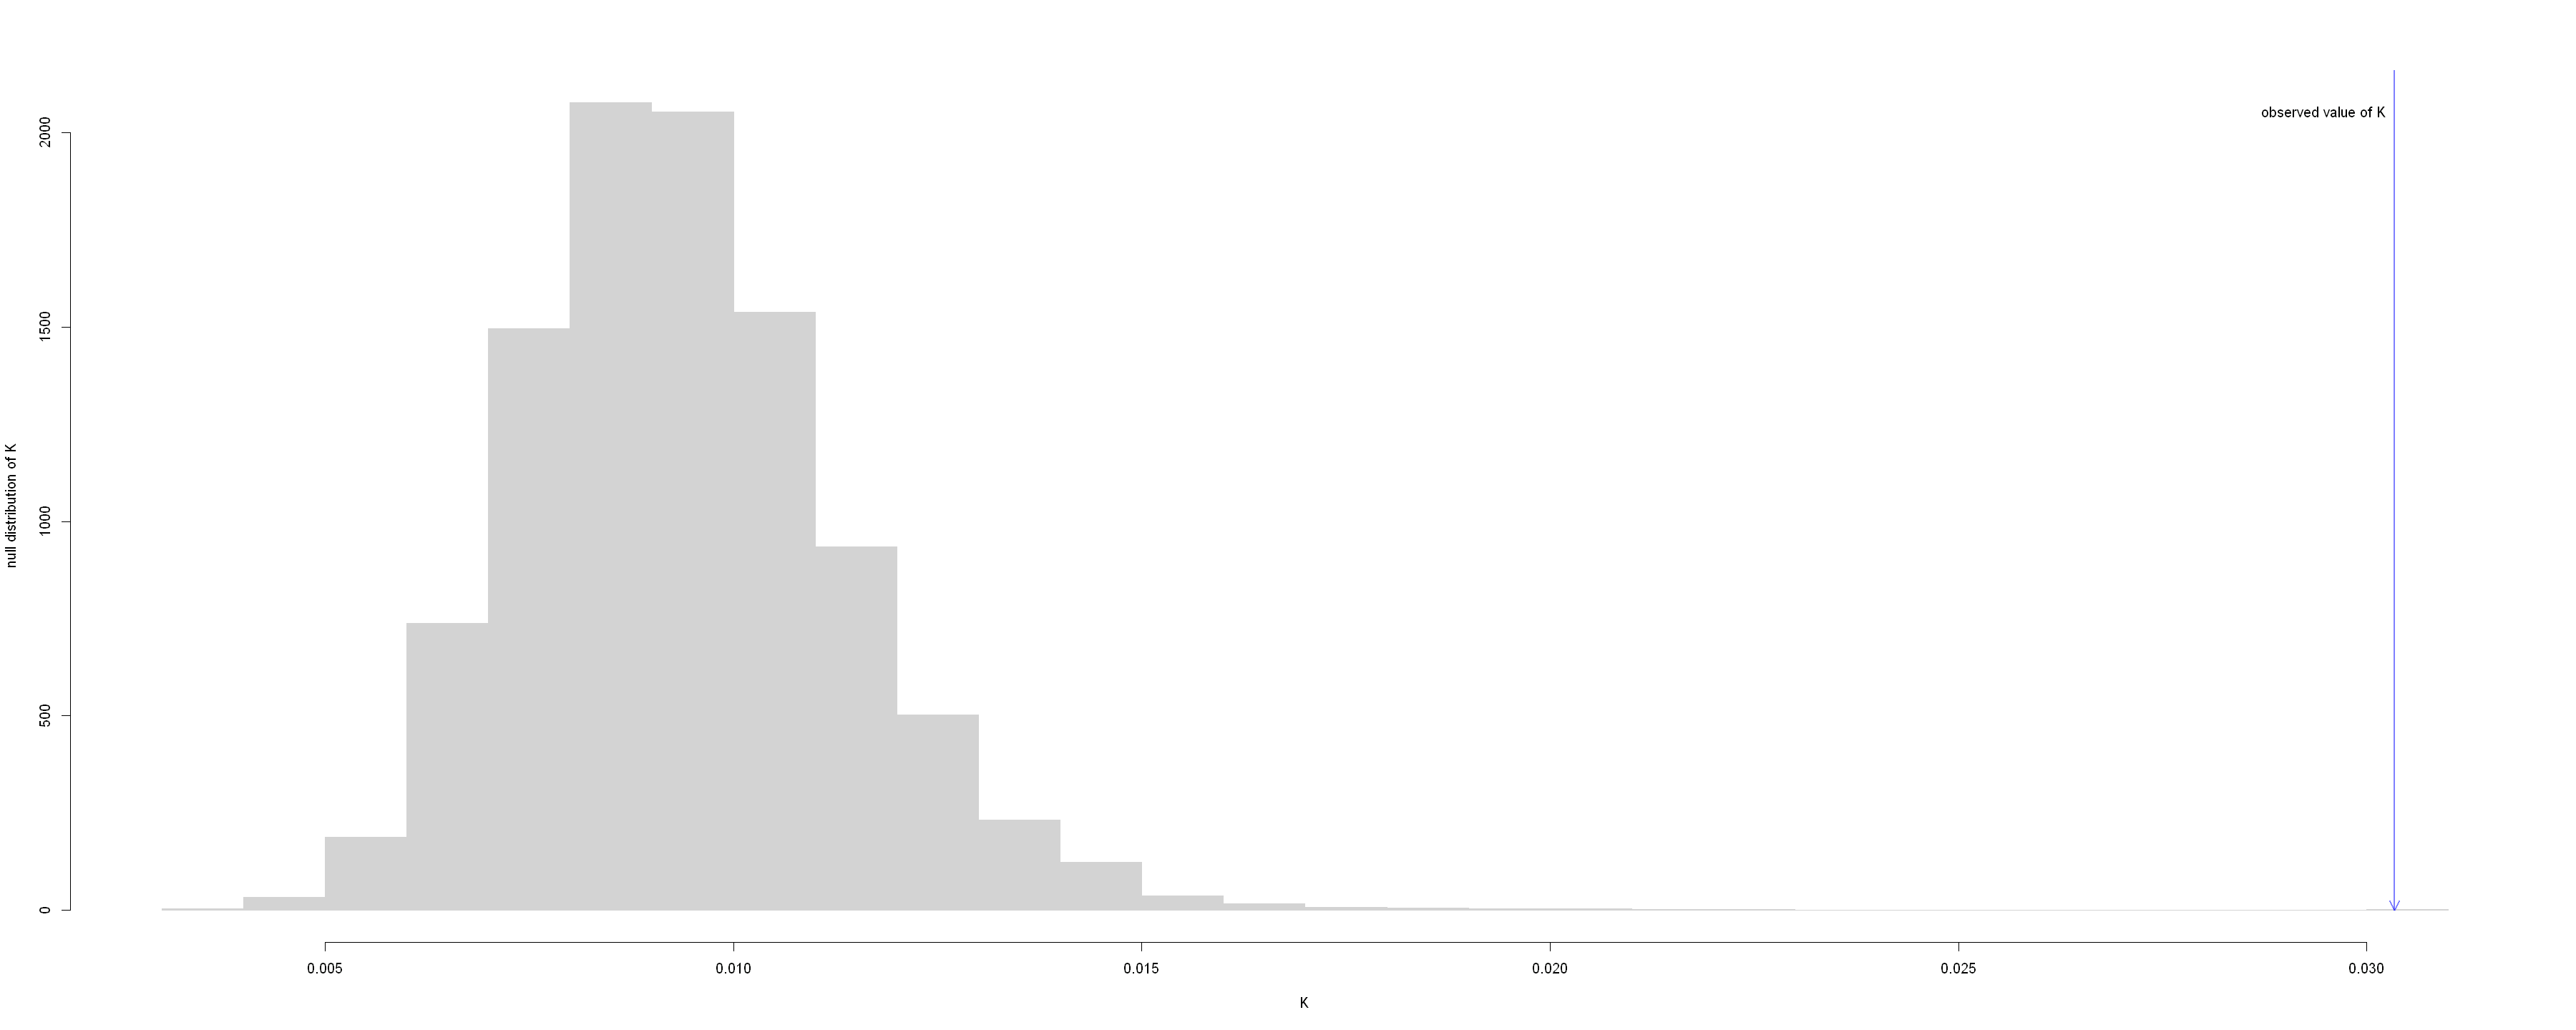

In [102]:
plot(bberg_rd)

In [103]:
bberg_srl <- phytools::phylosig(tree = phylo1005sp, x = setNames(srl1005$SRL, nm = srl1005$binominal), test = TRUE, nsim = 10000)
bberg_srl


Phylogenetic signal K : 0.0245586 
P-value (based on 10000 randomizations) : 6e-04 


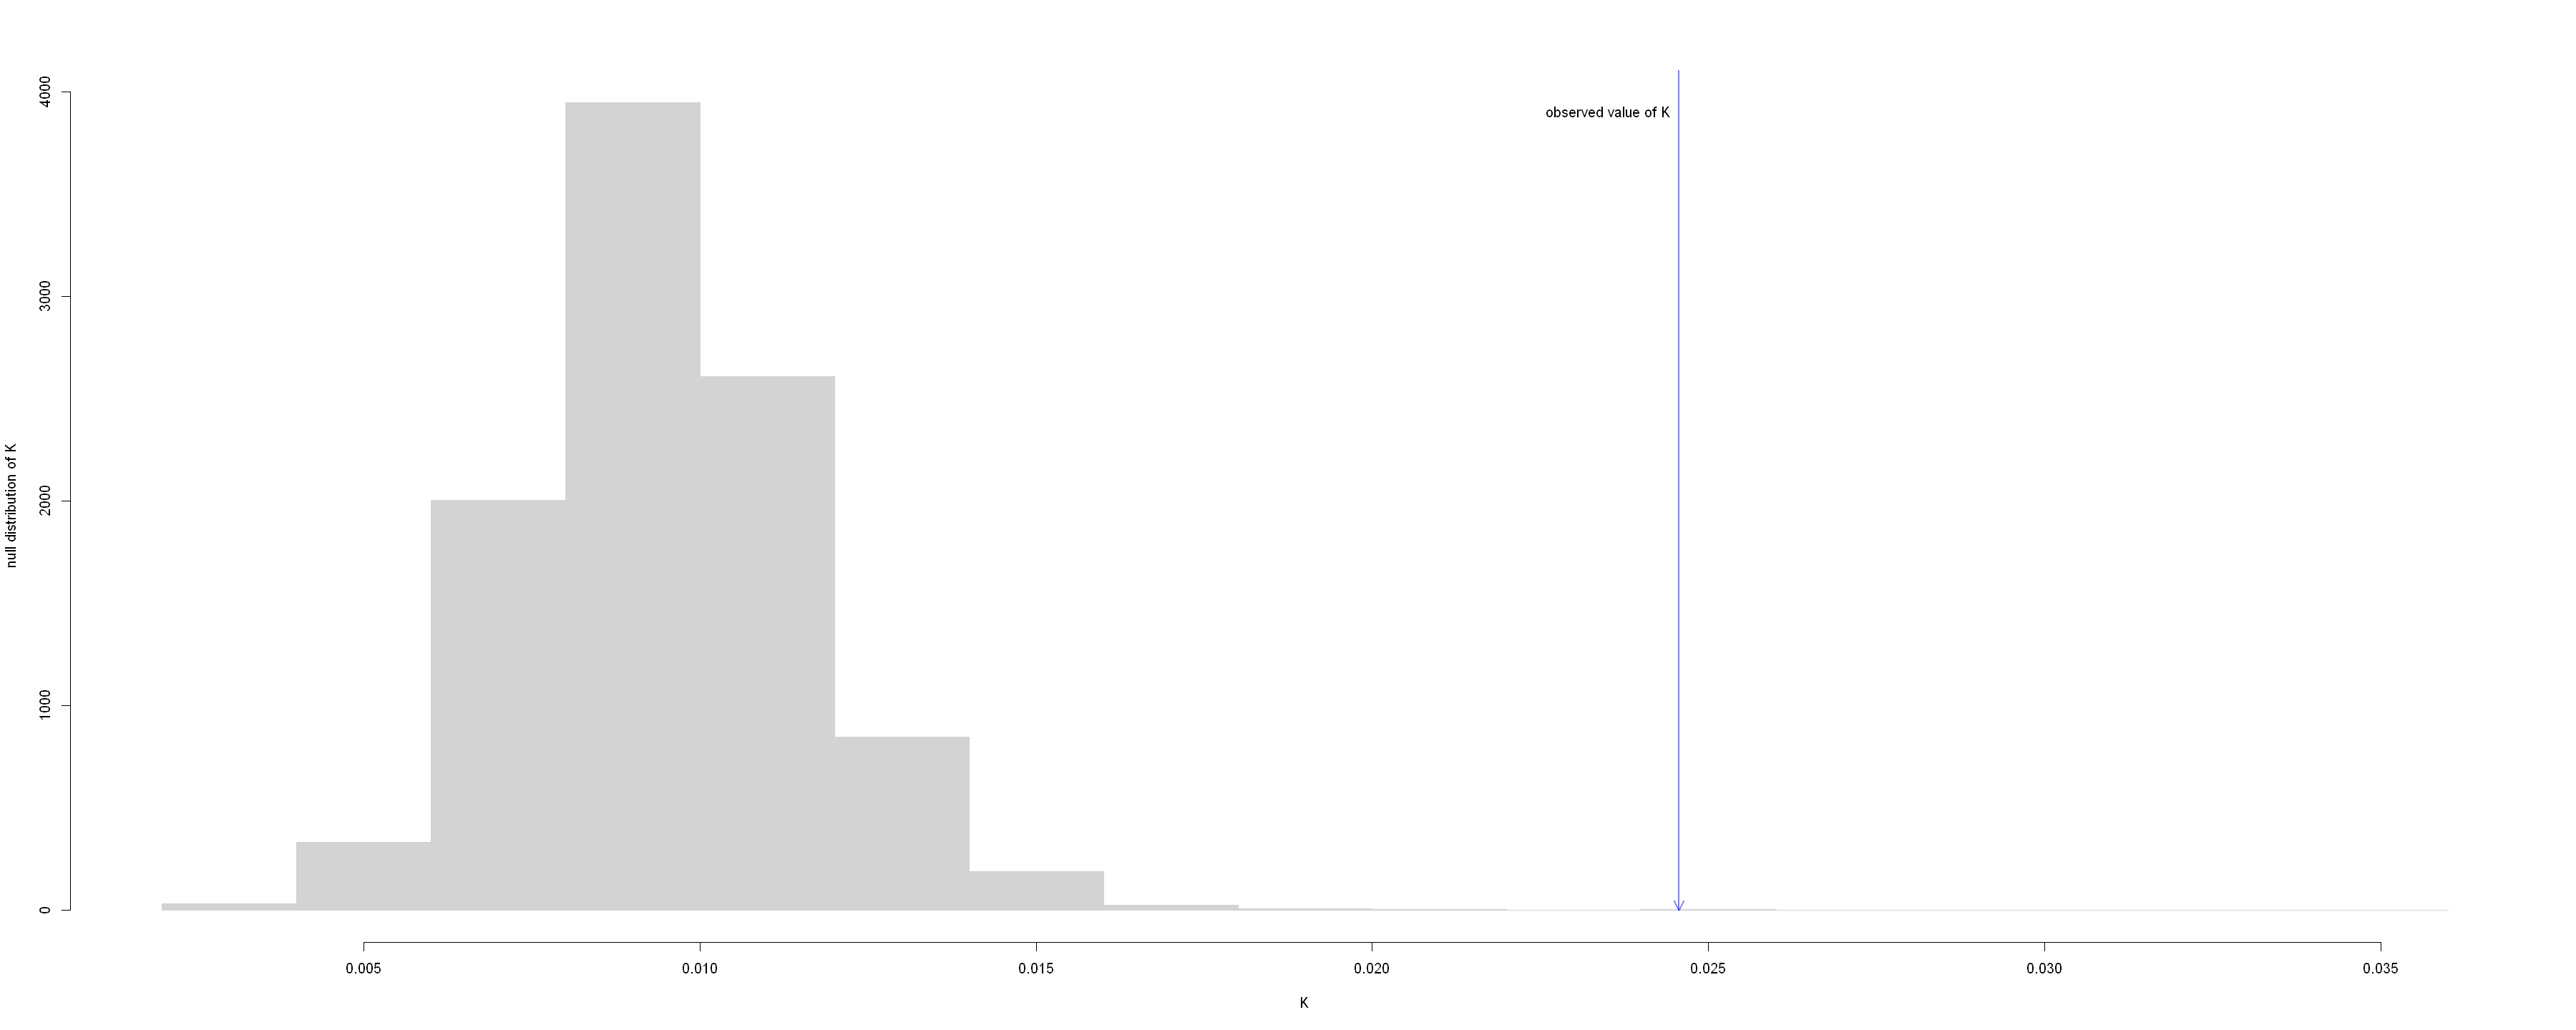

In [104]:
plot(bberg_srl)

In [ ]:
# now using Pagel's lambda tests
# lambda < 1 means that less phylogenetic signal than expected under a Brownian motion model of evolution

pagels_rd <- phytools::phylosig(tree = phylo1005sp, x = setNames(rd1005$RD, nm = rd1005$binominal), method = "lambda", test = TRUE)
pagels_rd

In [ ]:
plot(pagels_rd)

In [ ]:
pagels_srl <- phytools::phylosig(tree = phylo1005sp, x = setNames(srl1005$SRL, nm = srl1005$binominal), method = "lambda", test = TRUE)
pagels_srl

In [ ]:
plot(pagels_srl)

In [51]:
load("../rdata/IndependentACEs1005sp7states.RData")

In [52]:
phylo1005sp # has 1004 internal nodes


Phylogenetic tree with 1005 tips and 1004 internal nodes.

Tip labels:
  Rudbeckia_hirta, Ratibida_pinnata, Heliopsis_helianthoides, Liatris_aspera, Arnica_sororia, Arnica_fulgens, ...
Node labels:
  , , Spermatophyta, Mesangiospermae, mrcaott2ott121, eudicotyledons, ...

Rooted; includes branch length(s).

In [73]:
ace_states_1005sp_corhmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -234.4263 552.8526 556.6072        1 1005

Legend
      1       2       3       4       5       6       7 
   "AM"   "EcM" "EcMAM"   "ErM"    "NM"  "NMAM"    "OM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0001628846 0.0002167333 4.163396e-05 0.0002223881
(2,R1) 0.0007777061           NA 0.0000000010 1.000000e-09 0.0000000010
(3,R1) 0.0142864046 0.0000000010           NA 1.000000e-09 0.0000000010
(4,R1) 0.0000000010 0.0046701718 0.0000000010           NA 0.0000000010
(5,R1) 0.0006241327 0.0000000010 0.0000000010 1.000000e-09           NA
(6,R1) 0.0011555737 0.0007362476 0.0000000010 1.000000e-09 0.0000000010
(7,R1) 0.0201342663 0.0000000010 0.0000000010 1.000000e-09 0.0000000010
            (6,R1)       (7,R1)
(1,R1) 0.000787451 6.040978e-05
(2,R1) 0.000000001 1.000000e-09
(3,R1) 0.000000001 1.000000e-09
(4,R1) 0.000000001 1.000000e-09
(5,R1) 0.000000001 1.000000e-09
(6,R1)      

In [79]:
CORHMM_7STATES_LEGEND <- c("AM", "EcM", "EcMAM", "ErM", "NM", "NMAM", "OM")

In [80]:
paired_changes <- paired_dc_changes(phylogeny = phylo1005sp, rdextant = setNames(rd1005$RD, nm = rd1005$binominal), srlextant = setNames(srl1005$SRL, nm = srl1005$binominal), discextant = setNames(rd1005$state, nm = rd1005$binominal),
                 rdinternodes = ace_rd_1005sp_fastanc$ace, srlinternodes = ace_srl_1005sp_fastanc$ace, discprobinternodes = ace_states_1005sp_corhmm$states, discstates = CORHMM_7STATES_LEGEND)

In [89]:
head(paired_changes)

,shifts,delta_rd,delta_srl
,<chr>,<dbl>,<dbl>
1,AM_to_AM,0.0003089373,-0.4023092
2,AM_to_AM,-0.0273678257,9.6397540
3,AM_to_AM,-0.0084872944,-4.3530708
4,AM_to_AM,0.0015837408,-0.3831417
5,AM_to_AM,0.0314914682,-4.5764138
6,AM_to_AM,0.0086852662,-0.8333335


In [82]:
#----------------------------------------------------------------------
# CHANGES IN LOG RD WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

# the continuous trait change measured here is the (value of ancestor - value of descendent)
as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_rd), sd(df$delta_rd)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_ErM,AM_to_NM,AM_to_NMAM,AM_to_OM,EcM_to_AM,EcM_to_EcM,EcMAM_to_AM,EcMAM_to_EcMAM,ErM_to_EcM,ErM_to_ErM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.7118255,0.3451172,0.3052670,0.02252636,1.1384185,1.0429123,1.914718,0.02386532,0.7711861,0.6835122,0.9106550,1.021788,1.020155,0.9101583,1.660532,-0.08832099,0.910830
std,0.7719193,0.7401352,0.7482352,NA,0.8398503,0.7772696,NA,NA,0.7897889,0.7858760,0.8929675,NA,1.089433,0.8916683,NA,NA,0.818765


In [83]:
#----------------------------------------------------------------------
# CHANGES IN LOG SRL WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_srl), sd(df$delta_srl)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_ErM,AM_to_NM,AM_to_NMAM,AM_to_OM,EcM_to_AM,EcM_to_EcM,EcMAM_to_AM,EcMAM_to_EcMAM,ErM_to_EcM,ErM_to_ErM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,44.35745,12.50732,38.37705,-11.85765,24.70269,70.40304,369.6051,3.674124,24.72764,46.66016,60.53425,106.1214,96.4572,89.62367,97.94876,67.93638,63.82649
std,69.36099,29.30379,91.98765,NA,115.58206,84.83220,NA,NA,30.36389,50.13479,77.12015,NA,191.6938,113.12810,NA,NA,71.46667


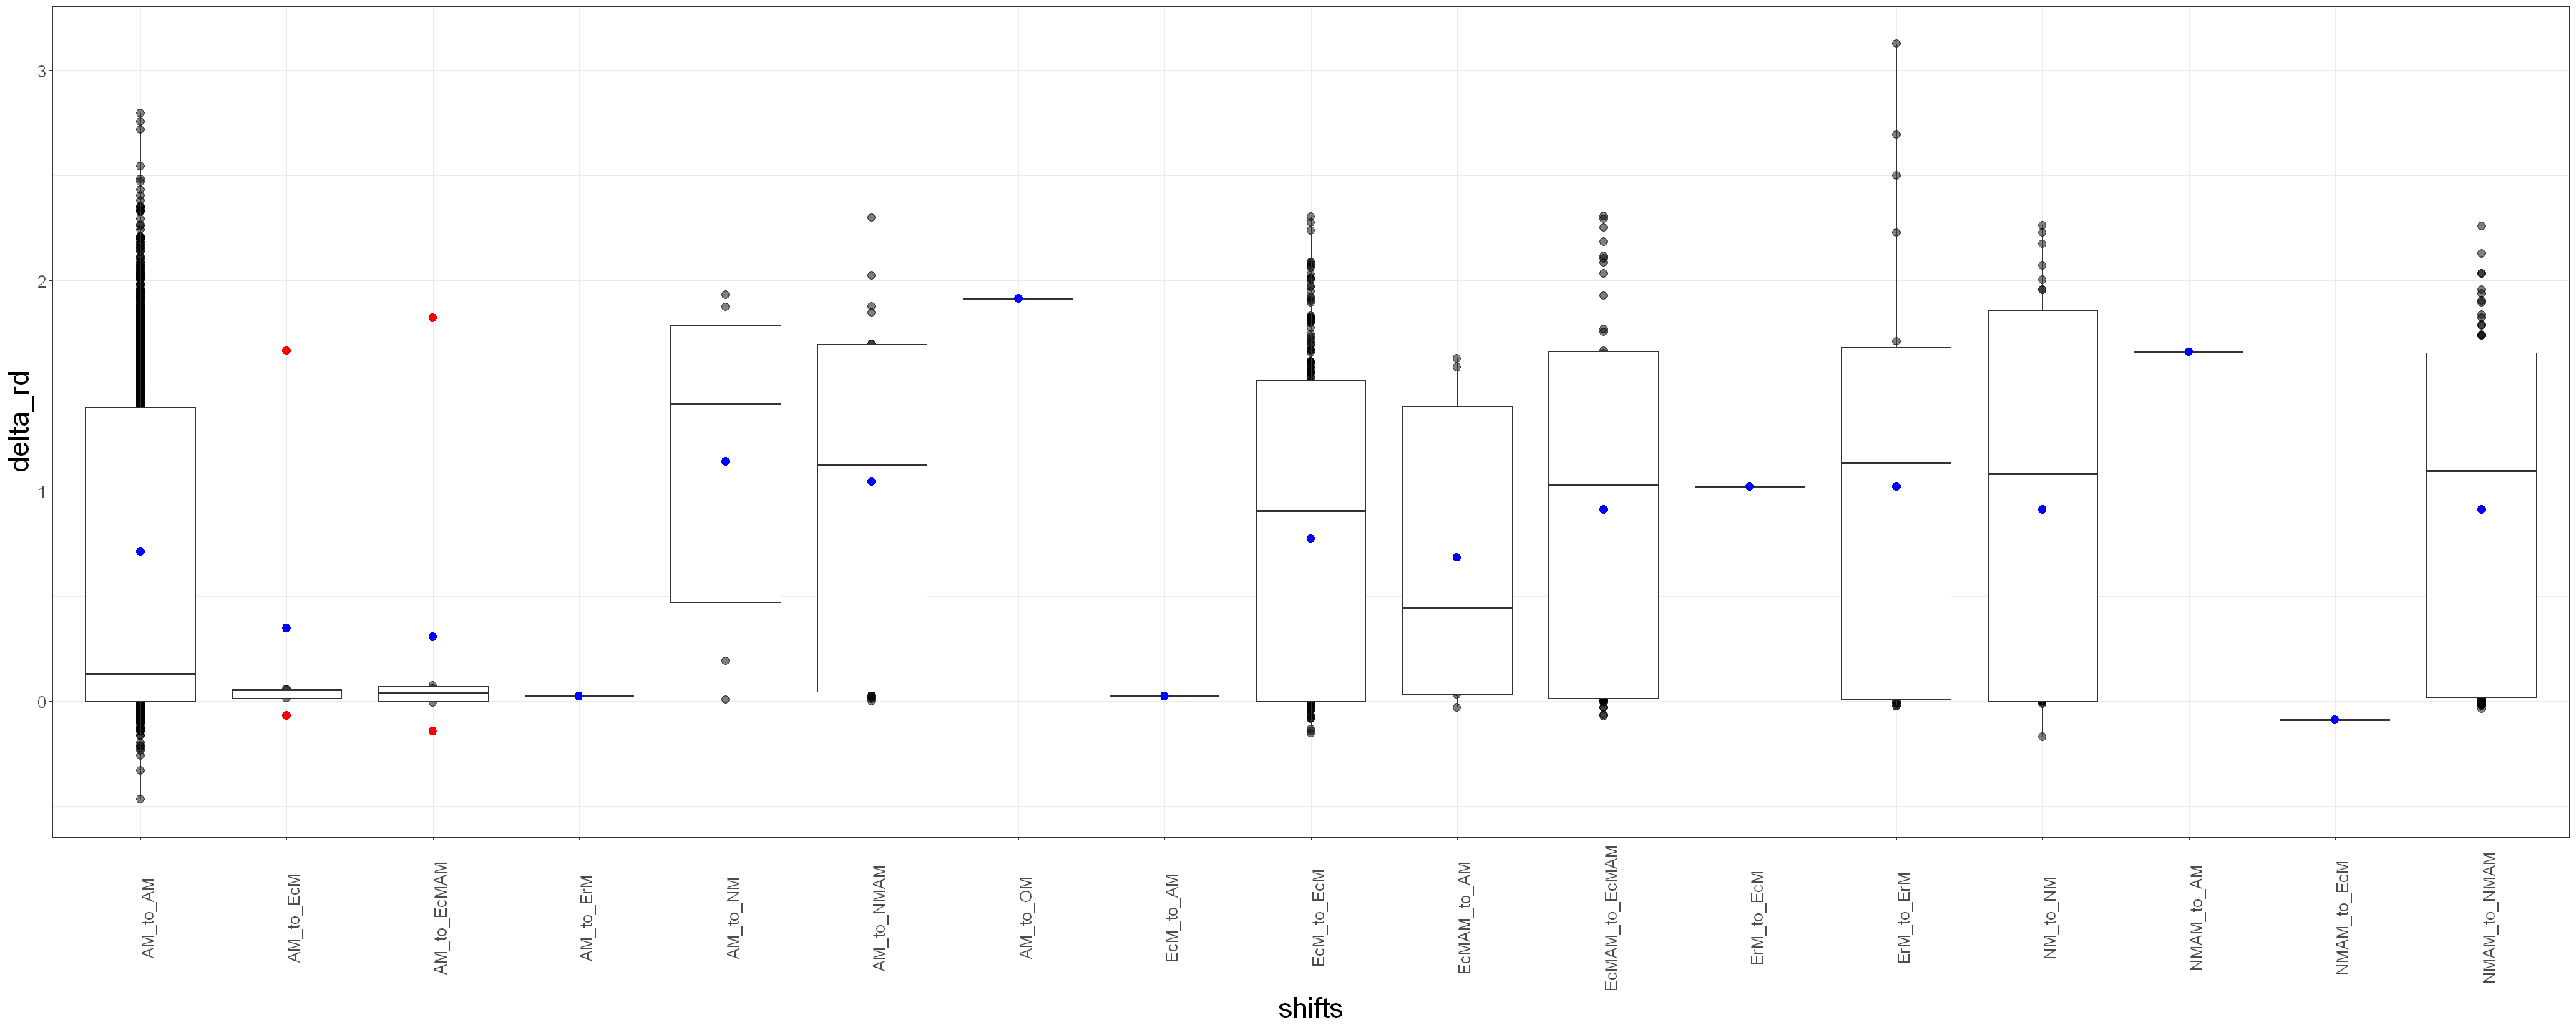

In [94]:
options(repr.plot.width = 30, repr.plot.height = 12)
ggplot2::ggplot(paired_changes, aes(x = shifts, y = delta_rd)) +
    geom_point(alpha=0.5, size = 3) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))

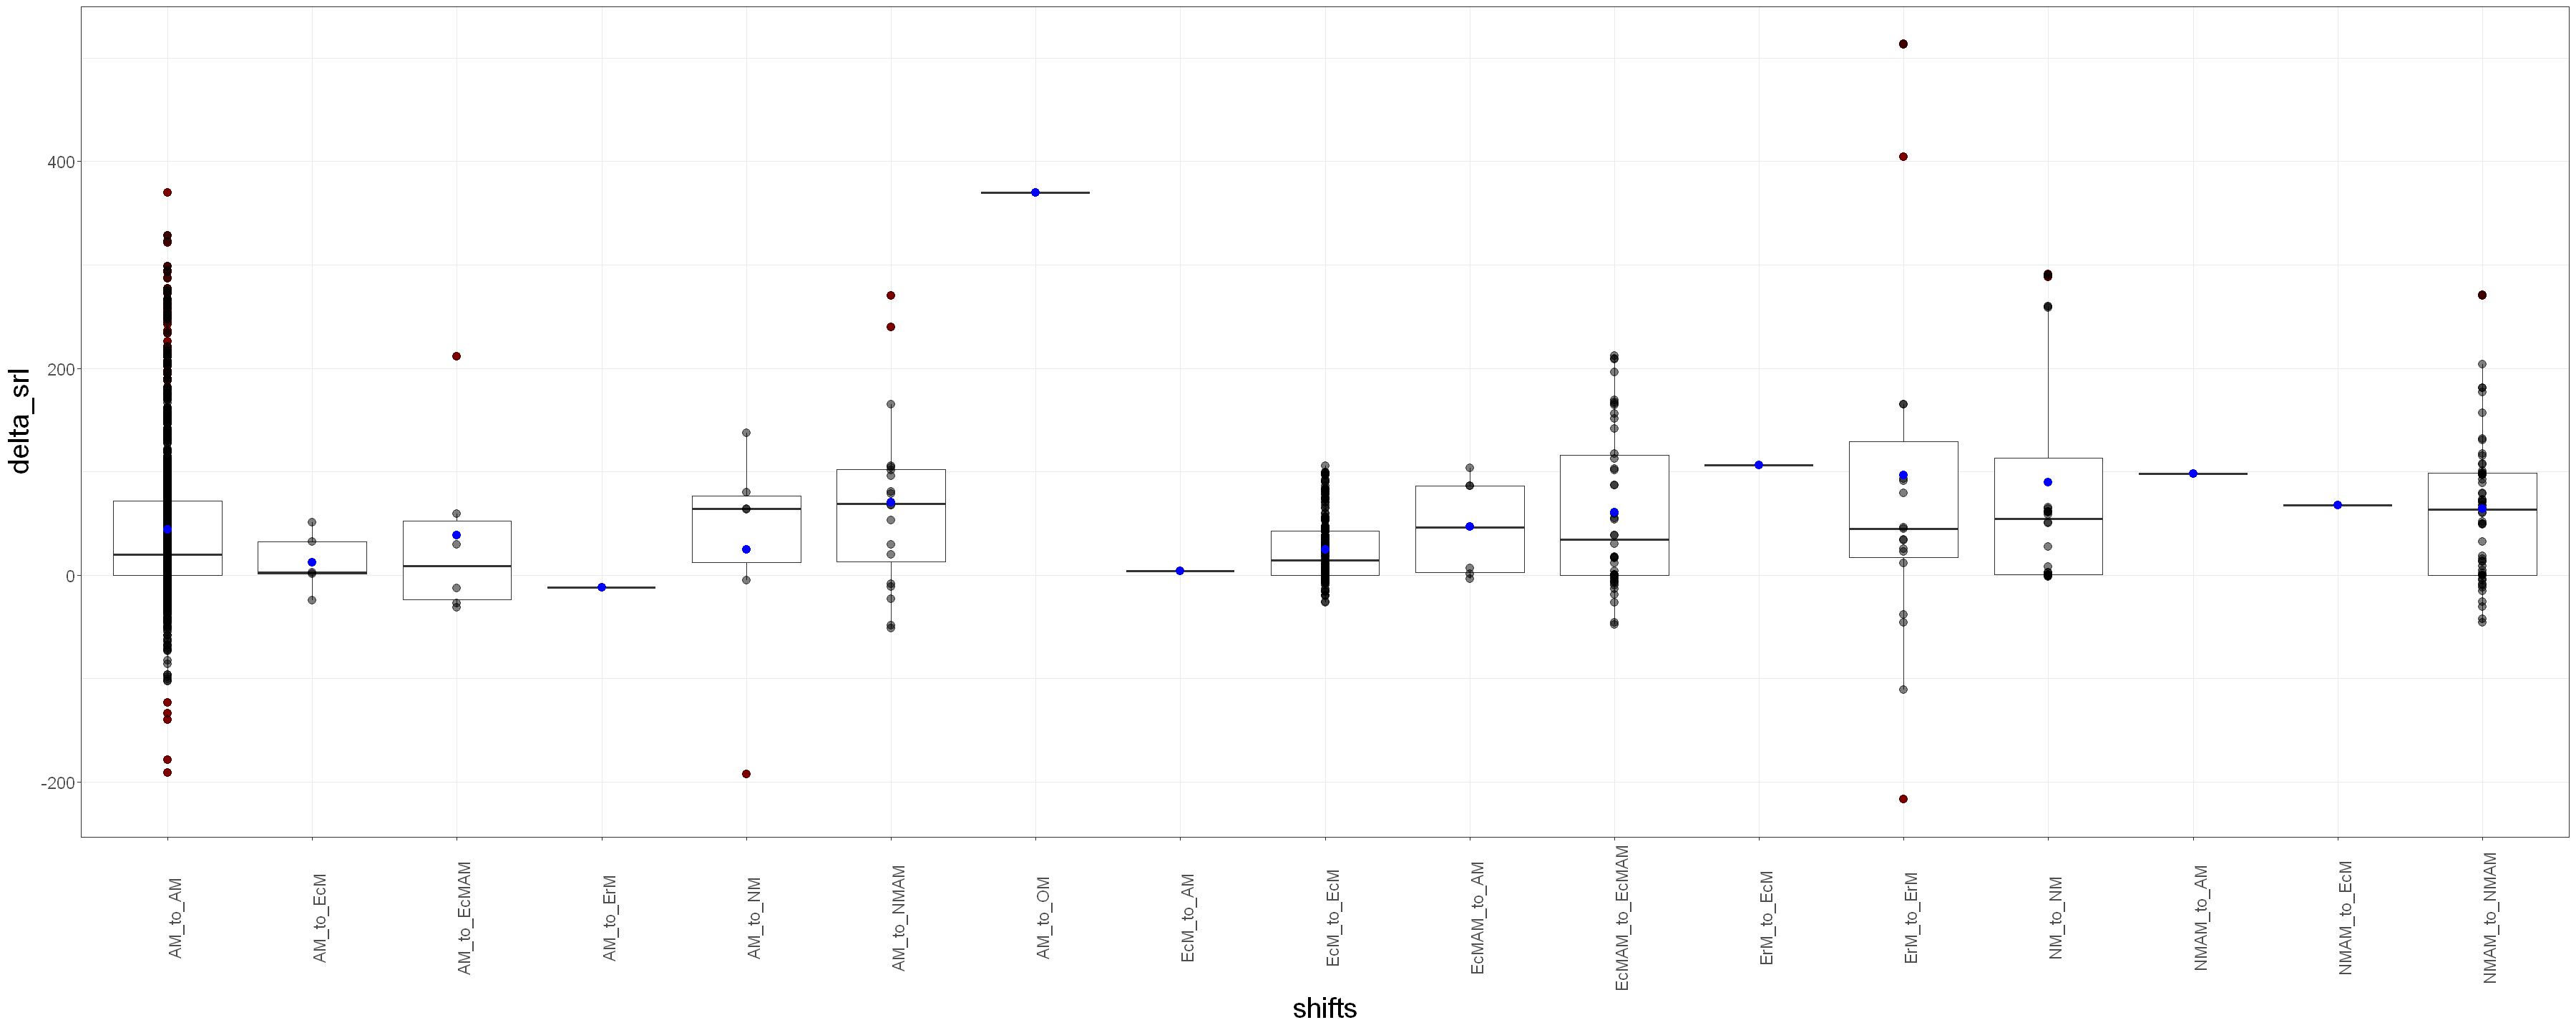

In [95]:
options(repr.plot.width = 30, repr.plot.height = 12)
ggplot2::ggplot(paired_changes, aes(x = shifts, y = delta_srl)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    geom_point(alpha=0.5, size = 3) +
    stat_summary(fun = mean, color = "blue", na.rm = FALSE, geom = "point", size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))